<a href="https://colab.research.google.com/github/dewianggrainimeita/PCVK_Ganjil_2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Hubungkan Google Colab dengan Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


== LANGKAH PRRAKTIKUM Modul 2 ==

In [2]:
#Import Library & Deklarasi Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path disesuaikan dengan struktur folder Google Drive kamu
path_gambar = '/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'

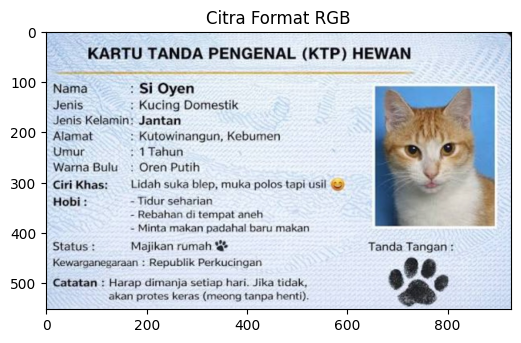

In [3]:
# Read image menggunakan OpenCV (Default BGR)
img = cv2.imread(path_gambar)

# Konversi BGR ke RGB agar warna sesuai di Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Tampilkan dengan Plotting Matplotlib
plt.figure(figsize=(6, 4))
plt.imshow(img_rgb)
plt.title("Citra Format RGB")
plt.axis('on')
plt.show()

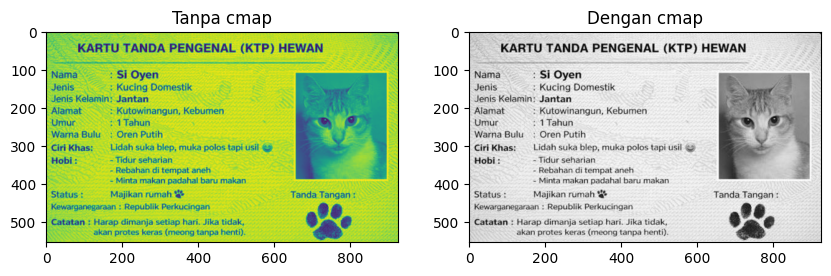

In [4]:
img_gray = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))

# Tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

# Dengan cmap 'gray'
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

plt.show()

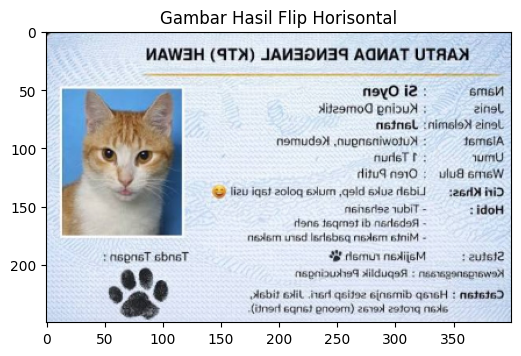

In [5]:
# Resize ke ukuran 400x250
img_small = cv2.resize(img_rgb, (400, 250))

# Flip Horisontal (1)
img_flip = cv2.flip(img_small, 1)

# Tampilkan dengan Canvas Lebar
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
ax.imshow(img_flip)
plt.title("Gambar Hasil Flip Horisontal")
plt.show()

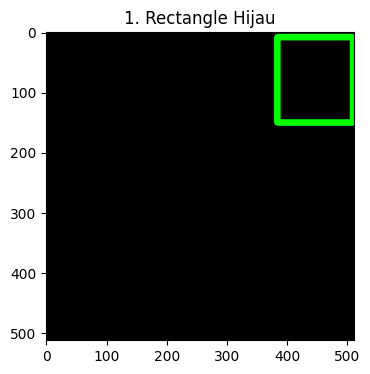

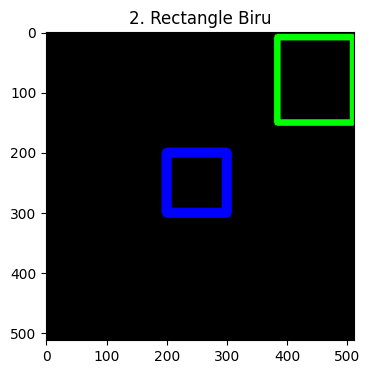

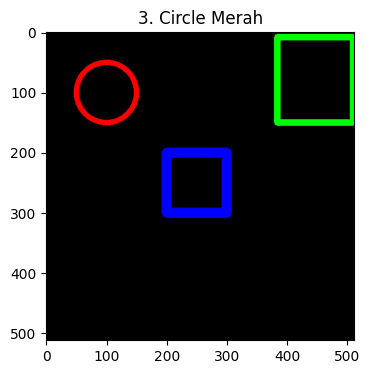

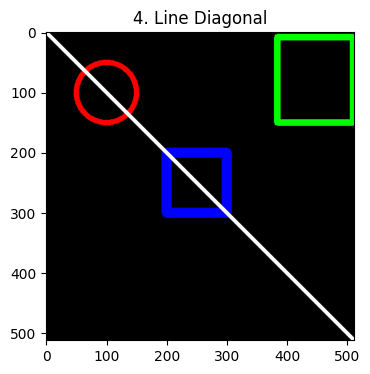

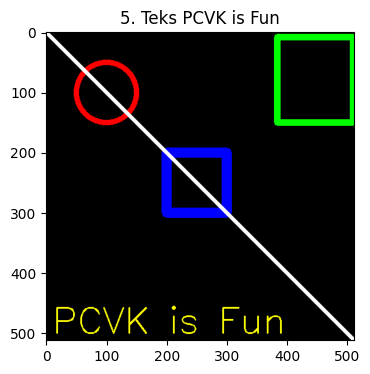

In [16]:
# 1. Buat Canvas Hitam (512x512 piksel, 3 channel)
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)

# 2. Menambahkan persegi panjang hijau
cv2.rectangle(black_img, pt1=(384, 8), pt2=(510, 150), color=(0, 255, 0), thickness=10)
plt.figure(figsize=(4, 4))
plt.imshow(black_img)
plt.title("1. Rectangle Hijau")
plt.show()

# 3. Menambahkan persegi biru
cv2.rectangle(black_img, pt1=(200, 200), pt2=(300, 300), color=(0, 0, 255), thickness=15)
plt.figure(figsize=(4, 4))
plt.imshow(black_img)
plt.title("2. Rectangle Biru")
plt.show()

# 4. Menambahkan lingkaran merah
cv2.circle(black_img, center=(100, 100), radius=50, color=(255, 0, 0), thickness=8)
plt.figure(figsize=(4, 4))
plt.imshow(black_img)
plt.title("3. Circle Merah")
plt.show()

# 5. Menambahkan garis diagonal putih
cv2.line(black_img, pt1=(0, 0), pt2=(512, 512), color=(255, 255, 255), thickness=5)
plt.figure(figsize=(4, 4))
plt.imshow(black_img)
plt.title("4. Line Diagonal")
plt.show()

# 6. Menambahkan Teks 'PCVK is Fun'
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(black_img, text='PCVK is Fun', org=(10, 500), fontFace=font, fontScale=2, color=(255, 255, 0), thickness=2, lineType=cv2.LINE_AA)
plt.figure(figsize=(4, 4))
plt.imshow(black_img)
plt.title("5. Teks PCVK is Fun")
plt.show()

== PERTANYAAN PRAKTIKUM ==
1. Hasil tampilan berbeda karena OpenCV membaca citra dalam format BGR, sedangkan Matplotlib (plt.imshow) membaca citra dalam format RGB. Hal ini menyebabkan kanal Merah dan Biru tertukar pada Matplotlib.

2. Visual tampilannya sama persis (hitam polos nilai 0). Namun ukuran memori int32 tepat 2x lipat lebih besar dibanding int16 karena dialokasikan 4 byte (32 bit) per elemen dibanding 2 byte (16 bit).

3. cv2.imshow() butuh antarmuka GUI sistem operasi lokal yang tidak dimiliki server cloud Google Colab (menyebabkan crash). Fungsi cv2_imshow() dari google.colab.patches hadir sebagai tambalan khusus untuk merender citra langsung di dalam notebook.

4. Kedua-duanya menampilkan warna asli (RGB). skimage.io.imread() otomatis membaca citra sebagai RGB, sementara cv2.cvtColor(..., cv2.COLOR_BGR2RGB) mengonversi BGR OpenCV menjadi RGB secara manual.

5. Nilai img.shape tidak berubah. Mengubah figsize hanya memperbesar luas kanvas tampilan Matplotlib, sedangkan mengubah ukuran citra (cv2.resize) memotong/menambah jumlah data piksel matriks asli.

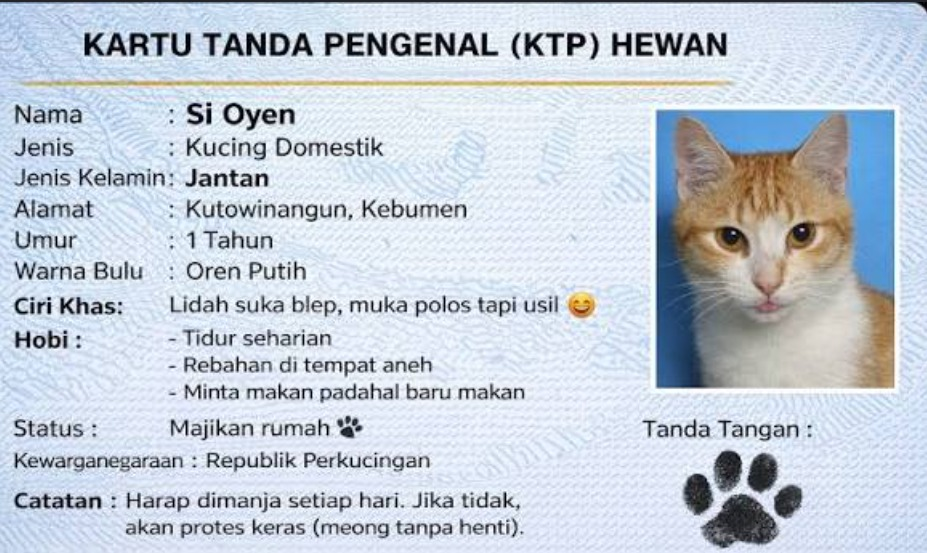

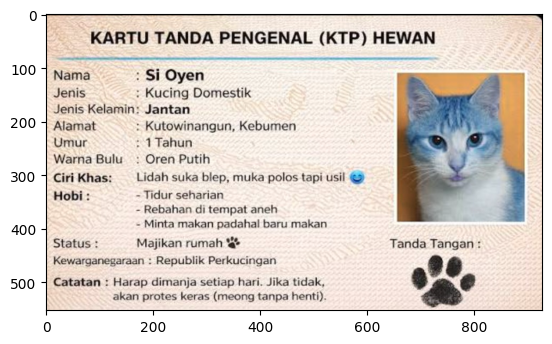

Piksel (y=100, x=100) BGR: [228 208 190]


In [7]:
# Pertanyaan No 1
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

path = '/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'
img_bgr = cv2.imread(path)

# Tampilan BGR OpenCV vs RGB Matplotlib
cv2_imshow(img_bgr)
plt.imshow(img_bgr)
plt.show()

# Cetak nilai piksel [B, G, R]
print("Piksel (y=100, x=100) BGR:", img_bgr[100, 100])

In [8]:
#Pertanyaan NO 2
import numpy as np

img_16 = np.zeros((530, 530, 3), dtype=np.int16)
img_32 = np.zeros((530, 530, 3), dtype=np.int32)

print(f"int16 -> min: {img_16.min()}, max: {img_16.max()}, nbytes: {img_16.nbytes} bytes")
print(f"int32 -> min: {img_32.min()}, max: {img_32.max()}, nbytes: {img_32.nbytes} bytes")

int16 -> min: 0, max: 0, nbytes: 1685400 bytes
int32 -> min: 0, max: 0, nbytes: 3370800 bytes


In [9]:
#Pertanyaan No 4
import cv2
from skimage import io

path = '/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'
img_sk = io.imread(path)
img_cv_rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

print("Piksel skimage  :", img_sk[100, 100])
print("Piksel OpenCV RGB:", img_cv_rgb[100, 100])

Piksel skimage  : [190 208 228]
Piksel OpenCV RGB: [190 208 228]


Shape sebelum figsize: (553, 927, 3)


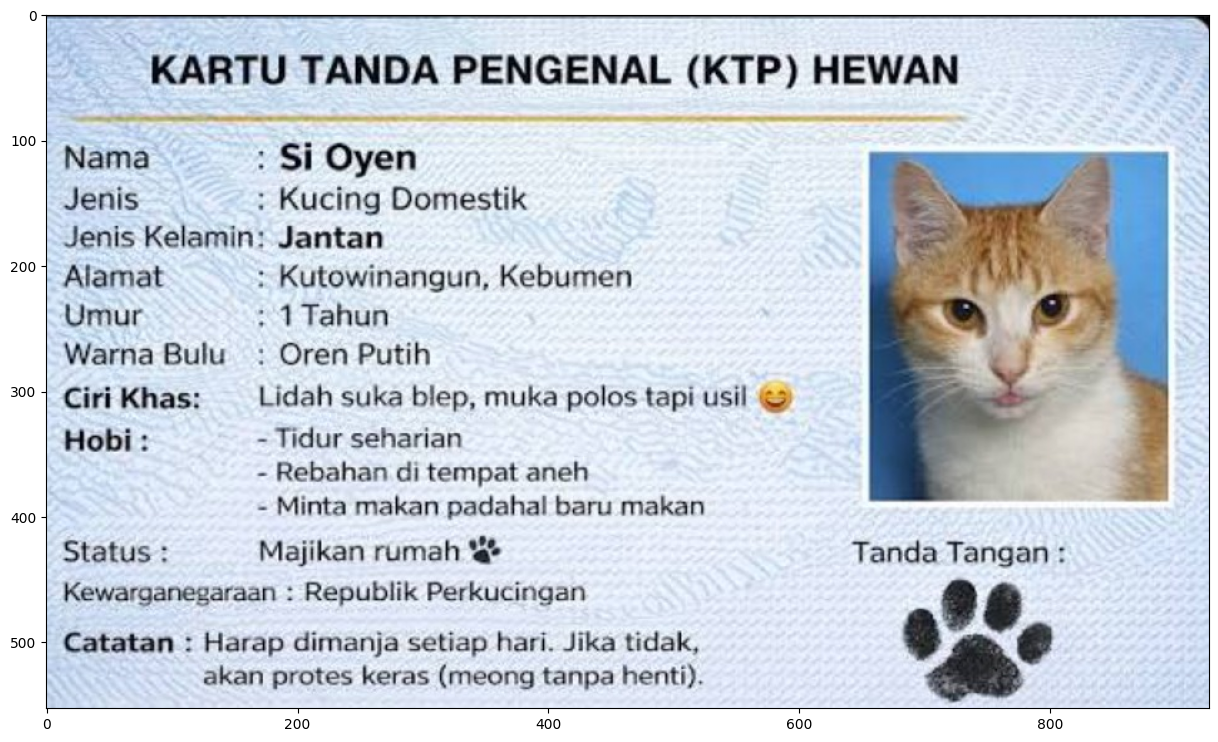

Shape sesudah figsize: (553, 927, 3)


In [10]:
#Pertanyaan No 5
import cv2
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'
img = cv2.imread(path)

print("Shape sebelum figsize:", img.shape)
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()
print("Shape sesudah figsize:", img.shape)

== TUGAS PRAKTIKUM ANALISA ==

Proses downscaling lalu upscaling tidak merubah rata-rata intensitas piksel secara signifikan (selisih rata-rata amat kecil), namun menghilangkan detail informasi/teks halus secara permanen. Nilai MSE yang tinggi menunjukkan adanya distorsi pada piksel-piksel detail akibat hilangnya informasi spasial saat proses downscaling.

In [13]:
import cv2
import numpy as np

# Membaca citra grayscale
img_gray = cv2.imread('/content/drive/MyDrive/PCVK/KTP Kucing.jpeg', cv2.IMREAD_GRAYSCALE)
h, w = img_gray.shape

# 1. Rata-rata intensitas awal
mean_orig = np.mean(img_gray)

# 2. Downscaling (mengecilkan) ke 25%
img_small = cv2.resize(img_gray, (w // 4, h // 4), interpolation=cv2.INTER_AREA)

# 3. Upscaling (membesarkan) kembali ke ukuran semula
img_restored = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_CUBIC)

# 4. Rata-rata intensitas setelah diproses
mean_restored = np.mean(img_restored)
mse = np.mean((img_gray.astype("float") - img_restored.astype("float")) ** 2)

print(f"Rata-rata Intensitas Asli  : {mean_orig:.4f}")
print(f"Rata-rata Intensitas Hasil : {mean_restored:.4f}")
print(f"Selisih Rata-rata          : {abs(mean_orig - mean_restored):.4f}")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")

Rata-rata Intensitas Asli  : 202.4534
Rata-rata Intensitas Hasil : 202.4696
Selisih Rata-rata          : 0.0162
Mean Squared Error (MSE)   : 418.3389


== TUGAS PRAKTIKUM APLIKASI ==

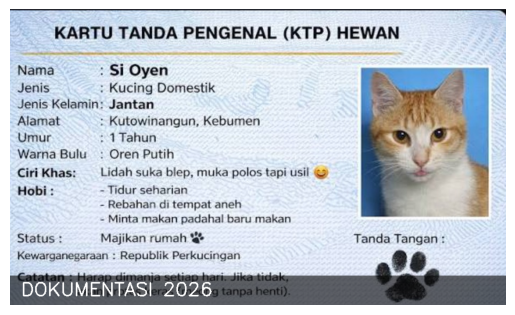

In [14]:
#1. Watermark / Label Adaptif
import cv2
import matplotlib.pyplot as plt

def add_adaptive_label(img_path, label_text="DOKUMENTASI 2026"):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Menentukan tinggi bar & ukuran teks secara proporsional
    bar_height = int(h * 0.1)
    font_scale = w / 800.0
    thickness = max(1, int(font_scale * 2))

    overlay = img.copy()
    cv2.rectangle(overlay, (0, h - bar_height), (w, h), (0, 0, 0), -1)
    img_labeled = cv2.addWeighted(overlay, 0.6, img, 0.4, 0)

    cv2.putText(img_labeled, label_text, (20, h - int(bar_height / 3)),
                cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    return cv2.cvtColor(img_labeled, cv2.COLOR_BGR2RGB)

plt.imshow(add_adaptive_label('/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'))
plt.axis('off')
plt.show()

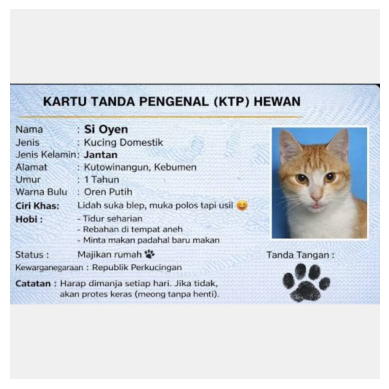

In [17]:
#2. Frame Produk 1:1 Adaptif
import cv2
import numpy as np
import matplotlib.pyplot as plt

def make_square_thumbnail(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Kanvas persegi berdasarkan sisi terpanjang
    max_side = max(h, w)
    canvas = np.full((max_side, max_side, 3), (240, 240, 240), dtype=np.uint8)

    # Menempatkan gambar di tengah kanvas
    x_offset = (max_side - w) // 2
    y_offset = (max_side - h) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img_rgb

    return canvas

# Gunakan path lengkap Google Drive
path_file = '/content/drive/MyDrive/PCVK/KTP Kucing.jpeg'
plt.imshow(make_square_thumbnail(path_file))
plt.axis('off')
plt.show()